In [1]:
from datascience import *
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

/Users/ayushthasale07/Sarg<3/Data8/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Average
l = [1, 2, 3, 5]

np.mean(l)

2.75

In [3]:
values = make_array(2, 3, 3, 9)

In [4]:


sd_table = Table().with_columns('Value', values)
sd_table



Value
2
3
3
9


In [5]:
average_value = np.mean(values)
average_value

4.25

In [6]:
deviations = values - average_value
sd_table = sd_table.with_column('Deviation', deviations)
sd_table

Value,Deviation
2,-2.25
3,-1.25
3,-1.25
9,4.75


In [7]:
sum(deviations)

0.0

In [8]:
sd_table = sd_table.with_column('Squared Deviation', deviations ** 2)
sd_table


Value,Deviation,Squared Deviation
2,-2.25,5.0625
3,-1.25,1.5625
3,-1.25,1.5625
9,4.75,22.5625


In [10]:
variance = np.mean(sd_table.column("Squared Deviation"))
variance

7.6875

In [11]:
sd = variance**0.5
sd

2.7726341266023544

In [12]:
np.std(values)

2.7726341266023544

In [13]:
# Chebyshev's Inequality

In [14]:
births = Table.read_table("baby.csv").drop("Maternal Smoker")
births.show(5)

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight
120,284,27,62,100
113,282,33,64,135
128,279,28,64,115
108,282,23,67,125
136,286,25,62,93


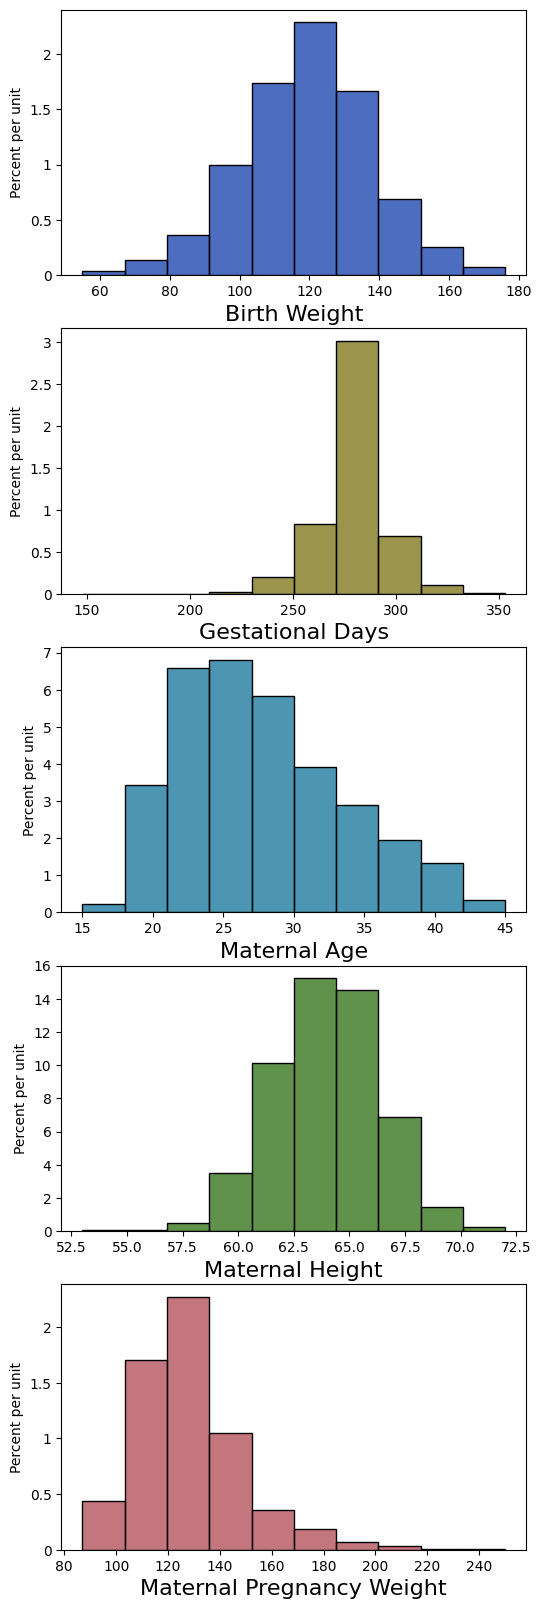

In [16]:
births.hist(overlay=False)

In [17]:
mpw = births.column('Maternal Pregnancy Weight')
mean = np.mean(mpw)
sd = np.std(mpw)
mean, sd


(128.4787052810903, 20.725449704280411)

In [18]:
within_3_SDs = births.where(
    'Maternal Pregnancy Weight', are.between(mean - 3*sd, mean + 3*sd))

In [19]:
# Proportion within 3 SDs of the mean

within_3_SDs.num_rows / births.num_rows


0.9863713798977853

In [21]:


1 - 1/3**2



0.8888888888888888

In [22]:
# See if Chebyshev's bounds work for distributions with various shapes

for feature in births.labels:
    values = births.column(feature)
    mean = np.mean(values)
    sd = np.std(values)
    print()
    print(feature)
    for z in make_array(2, 3, 4, 5):
        chosen = births.where(feature, are.between(mean - z*sd, mean + z*sd))
        proportion = chosen.num_rows / births.num_rows
        percent = round(proportion * 100, 2)
        print('Average plus or minus', z, 'SDs:', percent, '%')



Birth Weight
Average plus or minus 2 SDs: 94.89 %
Average plus or minus 3 SDs: 99.57 %
Average plus or minus 4 SDs: 100.0 %
Average plus or minus 5 SDs: 100.0 %

Gestational Days
Average plus or minus 2 SDs: 93.78 %
Average plus or minus 3 SDs: 98.64 %
Average plus or minus 4 SDs: 99.57 %
Average plus or minus 5 SDs: 99.83 %

Maternal Age
Average plus or minus 2 SDs: 94.89 %
Average plus or minus 3 SDs: 99.91 %
Average plus or minus 4 SDs: 100.0 %
Average plus or minus 5 SDs: 100.0 %

Maternal Height
Average plus or minus 2 SDs: 97.19 %
Average plus or minus 3 SDs: 99.66 %
Average plus or minus 4 SDs: 99.91 %
Average plus or minus 5 SDs: 100.0 %

Maternal Pregnancy Weight
Average plus or minus 2 SDs: 95.06 %
Average plus or minus 3 SDs: 98.64 %
Average plus or minus 4 SDs: 99.49 %
Average plus or minus 5 SDs: 99.91 %
